# 1 · Designing the MESS readout for arbitrary dephasing orders

Every SSFP coherence pathway carries an integer **dephasing order** $k$. In bSSFP all orders
refocus at the same time and add up coherently, $M_\text{bSSFP}=\sum_k S_k$; their interference
is what produces the dark bands. An unbalanced readout separates them instead: order $k$
refocuses at its own echo time $\text{TE}_k$, so one long ADC can sample any contiguous list of
orders $[k_1,\dots,k_N]$.

This notebook shows how MESS chooses the readout gradient for *any* such list (Algorithm 1 of the
paper), what the resulting sequences look like, and checks the Pulseq output against the design.
It only needs PyPulseq and matplotlib.

| symbol | meaning |
|---|---|
| $k$, $F_k^+$ | dephasing order; its transverse magnetisation right after the RF pulse |
| $[k_1,\dots,k_N]$ | acquired orders, in acquisition order |
| $G_1, G_2, G_3$ | zeroth moments of prephaser, readout and rewinder, in units of $u = N_\text{RO}/(2\,\text{FOV}_\text{RO})$ |
| $S_k$, $\text{TE}_k$ | echo of order $k$ and its echo time, $\text{TE}_k=\text{TE}_0-k\,\Delta\text{TE}$ |

> H. Hong *et al.*, Multi-Echo SSFP: A Method for Synthetic bSSFP MRI Contrast Without Banding
> Artifacts at High Field. *Magn Reson Med* 2026;96(4):1696–1708.
> [doi:10.1002/mrm.70472](https://doi.org/10.1002/mrm.70472)

In [1]:
import sys
import warnings
sys.path.insert(0, "..")                                  # use the repository's mess package
warnings.filterwarnings("ignore", module="cupy|sigpy")    # optional GPU back-ends of PyPulseq

import numpy as np
import matplotlib.pyplot as plt
import mess
from mess import plotting

plotting.use_style()

## Algorithm 1

The readout axis of every TR carries three lobes. One echo occupies $2u$ of the readout lobe, the
net moment per TR is $G_1+G_2+G_3=\pm 2$ (one full k-space width, i.e. one cycle of dephasing
across a voxel), and **order $k$ refocuses when the moment accumulated since the RF pulse equals
$-k\,(G_1+G_2+G_3)$**. For a contiguous list $[k_1,\dots,k_N]$:

$$
(i_0,\ s)=\begin{cases}(-k_1,\,-2) & k_1<k_N\\[2pt] (k_1,\,+2) & \text{otherwise}\end{cases}
\qquad G_1=-2i_0-1,\qquad G_2=2N,\qquad G_3=s+2(i_0-N)+1 .
$$

`mess.readout_moments(k1, kN)` is exactly this, and reproduces every sequence of Fig. 1 and Fig. S3
of the paper. The last column lists where each order refocuses.

In [2]:
family = [
    ("FISP / GRE",       (0, 0)),
    ("PSIF / SSFP-echo", (-1, -1)),
    ("DESS",             (0, -1)),
    ("DESS",             (-1, 0)),
    ("DESS",             (0, 1)),
    ("DESS",             (1, 0)),
    ("TESS",             (1, -1)),
    ("QESS",             (1, -2)),
    ("MESS",             (2, -3)),
    ("FID orders only",  (3, 0)),
]

print(f"{'sequence':17s} {'orders':>21s}   G1  G2  G3  sum   refocusing moment [u]")
print(f"{'bSSFP':17s} {'all, coherently':>21s} " + "".join(f"{g:+4d}" for g in mess.BSSFP_MOMENTS)
      + f"{0:+5d}")
for name, (k1, kN) in family:
    orders = mess.dephasing_orders(k1, kN)
    moments = mess.readout_moments(k1, kN)
    where = [mess.refocusing_moment(k, moments) for k in orders]
    print(f"{name:17s} {str(orders):>21s} " + "".join(f"{g:+4d}" for g in moments)
          + f"{sum(moments):+5d}   {where}")

sequence                         orders   G1  G2  G3  sum   refocusing moment [u]
bSSFP                   all, coherently   -1  +2  -1   +0
FISP / GRE                          [0]   -1  +2  +1   +2   [0]
PSIF / SSFP-echo                   [-1]   +1  +2  -1   +2   [2]
DESS                            [0, -1]   -1  +4  -1   +2   [0, 2]
DESS                            [-1, 0]   -3  +4  -3   -2   [-2, 0]
DESS                             [0, 1]   -1  +4  -5   -2   [0, 2]
DESS                             [1, 0]   -3  +4  +1   +2   [-2, 0]
TESS                         [1, 0, -1]   -3  +6  -1   +2   [-2, 0, 2]
QESS                     [1, 0, -1, -2]   -3  +8  -3   +2   [-2, 0, 2, 4]
MESS              [2, 1, 0, -1, -2, -3]   -5 +12  -5   +2   [-4, -2, 0, 2, 4, 6]
FID orders only            [3, 2, 1, 0]   -7  +8  +1   +2   [-6, -4, -2, 0]


## The sequences as extended phase graphs

`plotting.readout_figure` draws Fig. 1 of the paper directly from `mess.readout_moments`. The top
of each panel is the readout axis of one TR: prephaser $G_1$ (orange), readout $G_2$ (green) and
rewinder $G_3$ (blue), labelled with their moments in units of $u$. The readout has unit
amplitude, so time is measured in units of moment; prephaser and rewinder are drawn higher (at
most 2.25 times) and as long as their moments require. Below the lobes every line is one
pathway: $F_k$ enters the TR with the dephasing $k\,(G_1+G_2+G_3)$, follows the accumulated moment
and leaves the TR as $F_{k+1}$. It forms Echo $k$ (●) where it crosses zero (dashed) inside the
readout lobe. In bSSFP all pathways follow the same line and refocus together.

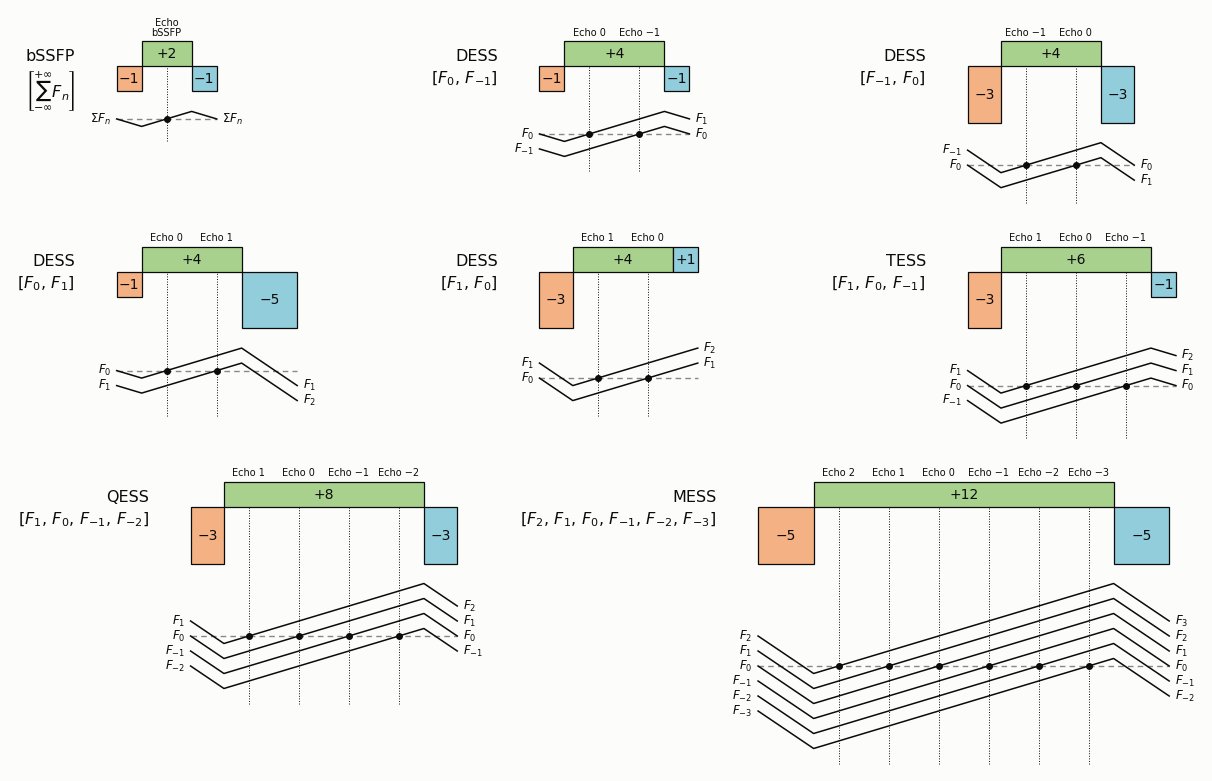

In [3]:
rows = [[("bSSFP", None), ("DESS", (0, -1)), ("DESS", (-1, 0))],
        [("DESS", (0, 1)), ("DESS", (1, 0)), ("TESS", (1, -1))],
        [("QESS", (1, -2)), ("MESS", (2, -3))]]
fig = plotting.readout_figure(rows)
fig.savefig("figures/readout_diagrams.png", dpi=150)
plt.show()

The four DESS panels acquire two neighbouring orders in either direction and on either side of
$k=0$. Reversing a list flips the sign of the net moment, so the same pathways refocus in the
opposite order. Nothing restricts the list to the middle of the graph either: `[3, 2, 1, 0]` in
the table above samples four FID-like orders only.

## From moments to a Pulseq sequence

`mess.MESS2D` builds a slice-selective sequence from the moments. The readout ramps are absorbed
into $G_1$ and $G_3$ (the ADC samples only the flat top), phase encoding is rewound every TR, and
the slice gradient is rewound exactly around the RF centre, so the readout axis is the only
unbalanced one. All timing is fixed when the protocol object is created. The protocol below uses
the in-plane geometry of the paper: 150 × 150 over 200 mm with a 5 µs dwell, flip angle 50°.

MESS2D  orders [2, 1, 0, -1, -2, -3]
  readout moments (G1, G2, G3) = (-5, +12, -5) x u,  u = 375.0 1/m
  flip angle 50 deg   TR 10.040 ms   TE_0 4.644 ms   delta TE 0.750 ms
  TE_k [ms]: k=+2: 3.145  k=+1: 3.895  k=+0: 4.644  k=-1: 5.394  k=-2: 6.145  k=-3: 6.895
  matrix 150 x 150   FOV 200 x 200 x 5 mm   scan time 1.5 s (+ dummies)


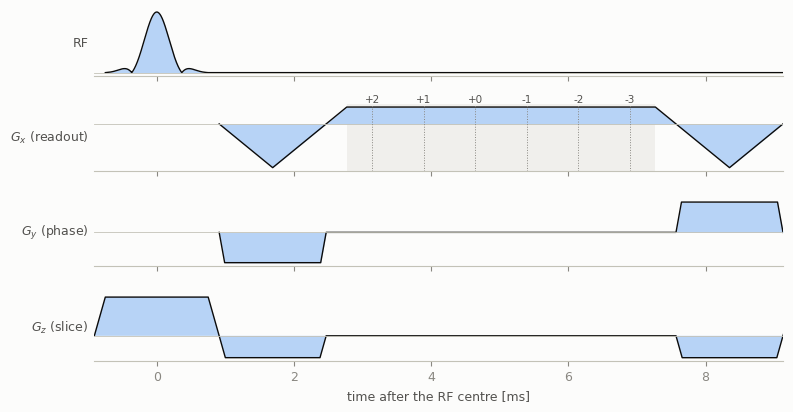

In [4]:
protocol = mess.MESS2D(orders=(2, -3), flip_angle=50)
print(protocol)
seq = protocol.make_sequence(phase_cycle=0.0)
plotting.sequence_diagram(protocol, seq)
plt.tight_layout()
plt.show()

### Check: the echoes are where Algorithm 1 puts them

PyPulseq integrates the real waveforms, ramps included. At the centre of every ADC window the
k-space position must equal $-k\,(G_1+G_2+G_3)\,u$, and the time since the RF centre must equal
$\text{TE}_k=\text{TE}_0-k\,\Delta\text{TE}$.

In [5]:
k_adc, t_adc, t_exc = mess.adc_kspace(seq)
n = protocol.matrix[0]
kx = k_adc[0].reshape(-1, protocol.n_echoes, n)             # (line, echo, sample)
te = t_adc.reshape(-1, protocol.n_echoes, n) - t_exc[:, None, None]
centre = lambda a: 0.5 * (a[..., n // 2 - 1] + a[..., n // 2])

print("  k   k at window centre [1/m]   design [1/m]   TE_k from the ADC [ms]   TE_0 - k dTE [ms]")
for j, k in enumerate(protocol.orders):
    print(f"{k:+3d}   {centre(kx)[:, j].mean():20.2f}   {mess.refocusing_moment(k, protocol.moments) * protocol.u:12.2f}"
          f"   {centre(te)[:, j].mean() * 1e3:20.4f}   {protocol.echo_times[k] * 1e3:17.4f}")

  k   k at window centre [1/m]   design [1/m]   TE_k from the ADC [ms]   TE_0 - k dTE [ms]
 +2               -1500.00       -1500.00                 3.1445              3.1445
 +1                -750.00        -750.00                 3.8945              3.8945
 +0                  -0.00           0.00                 4.6445              4.6445
 -1                 750.00         750.00                 5.3945              5.3945
 -2                1500.00        1500.00                 6.1445              6.1445
 -3                2250.00        2250.00                 6.8945              6.8945


## The matched bSSFP reference

`protocol.bssfp()` returns the balanced readout $(G_1,G_2,G_3)=(-1,2,-1)$ with the same RF pulse,
encoding, TR and $\text{TE}=\text{TE}_0$. It is the reference for the complex and magnitude sums
in notebooks 4 and 5.

In [6]:
print(protocol.bssfp())

MESS2D (bSSFP, balanced readout)
  readout moments (G1, G2, G3) = (-1, +2, -1) x u,  u = 375.0 1/m
  flip angle 50 deg   TR 10.040 ms   TE_0 4.644 ms   delta TE 0.000 ms
  matrix 150 x 150   FOV 200 x 200 x 5 mm   scan time 1.5 s (+ dummies)


## The 3D protocol used for the scans in the paper

The phantom and in vivo data of the paper were acquired on a 5T scanner with the slab-selective
`MESS3D`: orders $[2,\dots,-3]$, 1.3 mm isotropic over 200 × 200 × 100 mm³, 5 µs dwell, flip angles
20°, 50° and 80°. `examples/write_3d_sequences.py` writes these sequences and their bSSFP
references to `seq/3d/paper/`; `examples/write_2d_sequences.py` writes the 2D sequences of
notebooks 2–5 to `seq/2d/`. The published scans had TR = 9.74 ms: their RF pulse started 10 µs
into its block, whereas this code honours the scanner's 100 µs RF dead time, which gives
TR = 9.83 ms.

Simulating 11 250 phase-encoding steps of a 3D volume in MR-zero is impractical, so notebooks 2–5
use the 2D protocol above, which has the same in-plane geometry, readout and echo spacing.

In [7]:
paper = mess.MESS3D(orders=(2, -3), flip_angle=50, fov=(200e-3, 200e-3, 100e-3), matrix=(150, 150, 75))
print(paper)
print()
print(paper.bssfp())

MESS3D  orders [2, 1, 0, -1, -2, -3]
  readout moments (G1, G2, G3) = (-5, +12, -5) x u,  u = 375.0 1/m
  flip angle 50 deg   TR 9.830 ms   TE_0 4.495 ms   delta TE 0.750 ms
  TE_k [ms]: k=+2: 2.995  k=+1: 3.745  k=+0: 4.495  k=-1: 5.245  k=-2: 5.994  k=-3: 6.745
  matrix 150 x 150 x 75   FOV 200 x 200 x 100 mm   scan time 110.6 s (+ dummies)



MESS3D (bSSFP, balanced readout)
  readout moments (G1, G2, G3) = (-1, +2, -1) x u,  u = 375.0 1/m
  flip angle 50 deg   TR 9.830 ms   TE_0 4.495 ms   delta TE 0.000 ms
  matrix 150 x 150 x 75   FOV 200 x 200 x 100 mm   scan time 110.6 s (+ dummies)


**Next:** [notebook 2](02_steady_state.ipynb) simulates these sequences and checks how many dummy
TRs the simulation needs before it is in the steady state that the theory describes.